# 04 · Exploratory Data Analysis (EDA)

This notebook explores the final weekly modeling table.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

## 1. Load the modeling table

In Google Colab, this first tries the project parquet file. A CSV fallback is included for
convenience.

In [2]:
# Google Colab Drive setup
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

DATA = '/content/drive/MyDrive/biointerphase_data'
PROCESSED = os.path.join(DATA, 'processed')
PARQUET_PATH = os.path.join(PROCESSED, 'model_table_weekly.parquet')

if os.path.exists(PARQUET_PATH):
    df = pd.read_parquet(PARQUET_PATH)
elif os.path.exists('model_table_weekly_decoded.csv'):
    df = pd.read_csv('model_table_weekly_decoded.csv')
elif os.path.exists('/content/model_table_weekly_decoded.csv'):
    df = pd.read_csv('/content/model_table_weekly_decoded.csv')
else:
    raise FileNotFoundError('Could not find the weekly model table.')

df['week_start'] = pd.to_datetime(df['week_start'])

print('Shape:', df.shape)
print('Date range:', df['week_start'].min().date(), 'to', df['week_start'].max().date())
df.head()

Shape: (366, 47)
Date range: 2018-12-31 to 2025-12-29


,week_start,region,split,y_class,y_cellcount_max,n_habsos_samples,low_coverage,hab_class,hab_cellcount_max,nutr_chla_corr_ugL,nutr_cond_umho,nutr_do_mgL,nutr_do_sat_pct,nutr_nh3_mgL,nutr_nox_mgL,nutr_ph,nutr_po4_mgL,nutr_tkn_mgL,nutr_tn_mgL,nutr_tp_mgL,nutr_tss_mgL,nutr_turbidity_ntu,nutr_water_temp_c,has_nutrients,rain_total_mm,air_tmax_c,air_tmin_c,air_tmean_c,ksrq_pressure_hpa,ksrq_air_temp_c,ksrq_dew_point_c,ksrq_wind_speed,ksrq_wind_u,ksrq_wind_v,has_ksrq,uwnd_offshore,mote_temp_mean_c,mote_temp_max_c,has_mote,chl_box_median,chl_coastal_median,chl_coastal_anomaly,cyano_samples,cyano_detections,rain_2wk_mm,rain_4wk_mm,rain_8wk_mm
0,2018-12-31,sarasota_box,train,2.000,"1,303,204.000",73.000,0,2.000,"186,266,667.000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,15.748,28.333,10.000,20.794,NaN,NaN,NaN,NaN,NaN,NaN,0,-0.304,NaN,NaN,0,0.687,6.331,0.062,8.000,0.000,NaN,NaN,NaN
1,2019-01-07,sarasota_box,train,2.000,"2,428,000.000",107.000,0,2.000,"1,303,204.000",NaN,"30,314.152",7.044,87.531,NaN,NaN,7.707,NaN,NaN,NaN,NaN,NaN,NaN,20.005,1,0.000,26.111,6.111,17.143,NaN,NaN,NaN,NaN,NaN,NaN,0,-1.467,NaN,NaN,0,0.785,6.225,0.550,8.000,2.000,15.748,NaN,NaN
2,2019-01-14,sarasota_box,train,2.000,"282,720.000",93.000,0,2.000,"2,428,000.000",NaN,"2,040.693",7.269,76.263,NaN,NaN,7.520,NaN,NaN,NaN,NaN,NaN,NaN,18.737,1,1.524,26.111,3.333,13.968,NaN,NaN,NaN,NaN,NaN,NaN,0,0.663,NaN,NaN,0,0.747,5.929,0.265,NaN,NaN,1.524,NaN,NaN
3,2019-01-21,sarasota_box,train,0.000,667.000,76.000,0,2.000,"282,720.000",NaN,"6,454.336",6.585,67.686,NaN,NaN,7.627,NaN,NaN,NaN,NaN,NaN,NaN,17.385,1,56.134,26.111,4.444,14.762,NaN,NaN,NaN,NaN,NaN,NaN,0,-3.751,NaN,NaN,0,0.870,6.499,0.540,NaN,NaN,57.658,73.406,NaN
4,2019-01-28,sarasota_box,train,0.000,333.000,106.000,0,0.000,667.000,NaN,"6,454.336",6.585,67.686,NaN,NaN,7.627,NaN,NaN,NaN,NaN,NaN,NaN,17.385,0,0.508,26.667,4.444,15.476,NaN,NaN,NaN,NaN,NaN,NaN,0,-2.838,NaN,NaN,0,0.982,4.830,-0.595,NaN,NaN,56.642,58.166,NaN


## 2. Dataset overview and sanity checks

In [3]:
overview = pd.DataFrame({
    'value': [
        len(df),
        df.shape[1],
        df['week_start'].min(),
        df['week_start'].max(),
        df['week_start'].duplicated().sum(),
        df['region'].nunique()
    ]
}, index=[
    'rows', 'columns', 'first_week', 'last_week',
    'duplicate_week_rows', 'number_of_regions'
])
overview

,value
rows,366
columns,47
first_week,2018-12-31 00:00:00
last_week,2025-12-29 00:00:00
duplicate_week_rows,0
number_of_regions,1


In [4]:
split_order = ['train', 'validate', 'test', 'excluded']
df['split'].value_counts().reindex(split_order).to_frame('weeks')

,weeks
split,
train,157
validate,53
test,52
excluded,104


In [5]:
df.select_dtypes(include=np.number).describe().T

,count,mean,std,min,25%,50%,75%,max
y_class,303.000,0.482,0.825,0.000,0.000,0.000,1.000,2.000
y_cellcount_max,303.000,"774,976.515","4,507,223.487",0.000,0.000,333.000,"23,166.500","53,724,050.000"
n_habsos_samples,304.000,63.961,41.526,1.000,12.750,73.000,91.250,170.000
low_coverage,366.000,0.284,0.452,0.000,0.000,0.000,1.000,1.000
hab_class,304.000,0.487,0.828,0.000,0.000,0.000,1.000,2.000
hab_cellcount_max,304.000,"1,385,146.549","11,551,168.267",0.000,0.000,333.000,"23,999.750","186,266,667.000"
nutr_chla_corr_ugL,302.000,28.369,36.660,1.967,9.734,15.400,29.038,266.017
nutr_cond_umho,365.000,"14,520.014","16,375.081",313.635,"2,871.519","7,002.839","25,721.647","54,540.000"
nutr_do_mgL,365.000,5.267,1.415,0.674,4.155,5.261,6.291,9.079
nutr_do_sat_pct,365.000,66.962,18.540,5.801,53.802,63.749,82.318,108.873


### Analysis subsets

In [6]:
train_df = df[(df['split'] == 'train') & df['y_class'].notna()].copy()
val_df = df[(df['split'] == 'validate') & df['y_class'].notna()].copy()

# Keep test predictors available for coverage/drift checks, but do not use test y_class below.
test_df = df[df['split'] == 'test'].copy()

print('Labeled training weeks:', len(train_df))
print('Labeled validation weeks:', len(val_df))
print('Test weeks kept as holdout:', len(test_df))

Labeled training weeks: 141
Labeled validation weeks: 52
Test weeks kept as holdout: 52


### Understanding the final dataset

The final modeling dataset contains 366 weekly observations and 47 variables covering the Sarasota study region from late 2018 through 2025. 

Each row represents one week of current HAB and environmental conditions, while `y_class` represents the HAB severity observed during the following week. 

The dataset contains no duplicate weekly records. 

The data are split chronologically into training (2019–2021), validation (2024), and testing (2025), while 2022–2023 are excluded because of low HABSOS sampling coverage.

## 3. Training target distribution

In [7]:
target_counts = train_df['y_class'].value_counts().sort_index().to_frame('count')
target_counts['percent'] = 100 * target_counts['count'] / target_counts['count'].sum()
target_counts.index = ['Class 0', 'Class 1', 'Class 2']
target_counts

,count,percent
Class 0,91,64.539
Class 1,9,6.383
Class 2,41,29.078


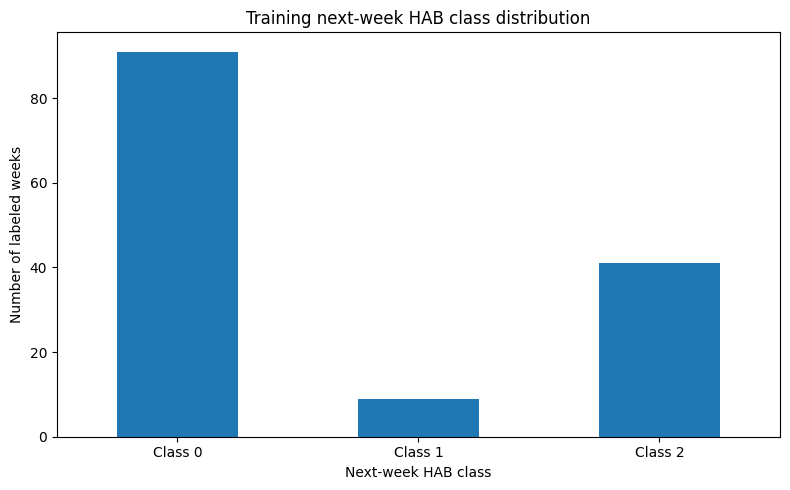

In [8]:
ax = target_counts['count'].plot(kind='bar', figsize=(8,5))
ax.set_title('Training next-week HAB class distribution')
ax.set_xlabel('Next-week HAB class')
ax.set_ylabel('Number of labeled weeks')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Actual result:** 

The next-week HAB target is imbalanced in the training data. Of the 141 labeled training weeks, 91 (64.5%) are Class 0, 9 (6.4%) are Class 1, and 41 (29.1%) are Class 2. 

Class 1 is especially underrepresented, which may make it difficult for a model to learn patterns associated with this class. 

## 4. Current-week → next-week HAB persistence

This is important because the current bloom state is itself available as a predictor.

In [9]:
transition_counts = pd.crosstab(
    train_df['hab_class'], train_df['y_class']
).reindex(index=[0,1,2], columns=[0,1,2], fill_value=0)

transition_pct = transition_counts.div(transition_counts.sum(axis=1), axis=0) * 100

print('Counts:')
display(transition_counts)
print('Row percentages:')
display(transition_pct.round(1))

Counts:


y_class,0,1,2
hab_class,,,
0,79,8,1
1,5,1,2
2,3,0,37


Row percentages:


y_class,0,1,2
hab_class,,,
0,89.800,9.100,1.100
1,62.500,12.500,25.000
2,7.500,0.000,92.500


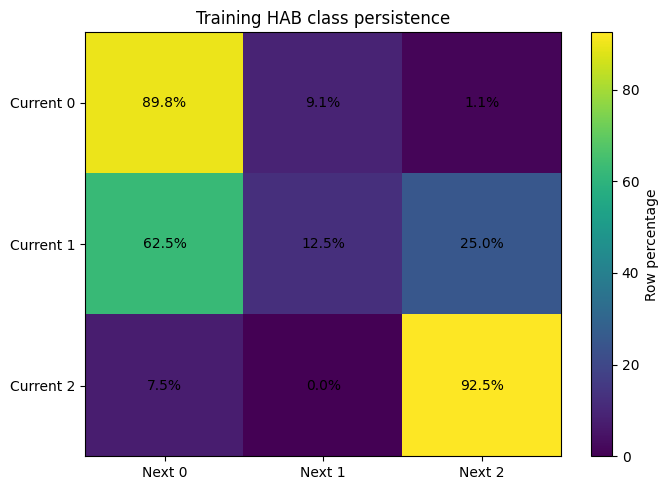

In [10]:
fig = plt.figure(figsize=(7,5))
plt.imshow(transition_pct.values, aspect='auto')
plt.colorbar(label='Row percentage')
plt.xticks([0,1,2], ['Next 0','Next 1','Next 2'])
plt.yticks([0,1,2], ['Current 0','Current 1','Current 2'])
plt.title('Training HAB class persistence')

for i in range(3):
    for j in range(3):
        plt.text(j, i, f'{transition_pct.iloc[i,j]:.1f}%', ha='center', va='center')

plt.tight_layout()
plt.show()

**Actual result:** current Class 0 stays Class 0 about **89.8%** of the time, while current
Class 2 stays Class 2 about **92.5%** of the time. There is only **one** direct Class-0 →
Class-2 transition in the training data.

This suggests that HAB conditions are highly persistent from week to week and that the current HAB class may be one of the strongest predictors of next-week HAB severity.

## 5. Missing-data EDA

In [12]:
missingness = df.isna().mean().mul(100).sort_values(ascending=False).to_frame('missing_percent')
missingness

,missing_percent
nutr_turbidity_ntu,97.268
cyano_detections,60.383
cyano_samples,60.383
ksrq_pressure_hpa,50.273
ksrq_dew_point_c,50.273
ksrq_wind_speed,50.273
ksrq_wind_u,50.273
ksrq_air_temp_c,50.273
ksrq_wind_v,50.273
mote_temp_mean_c,47.814


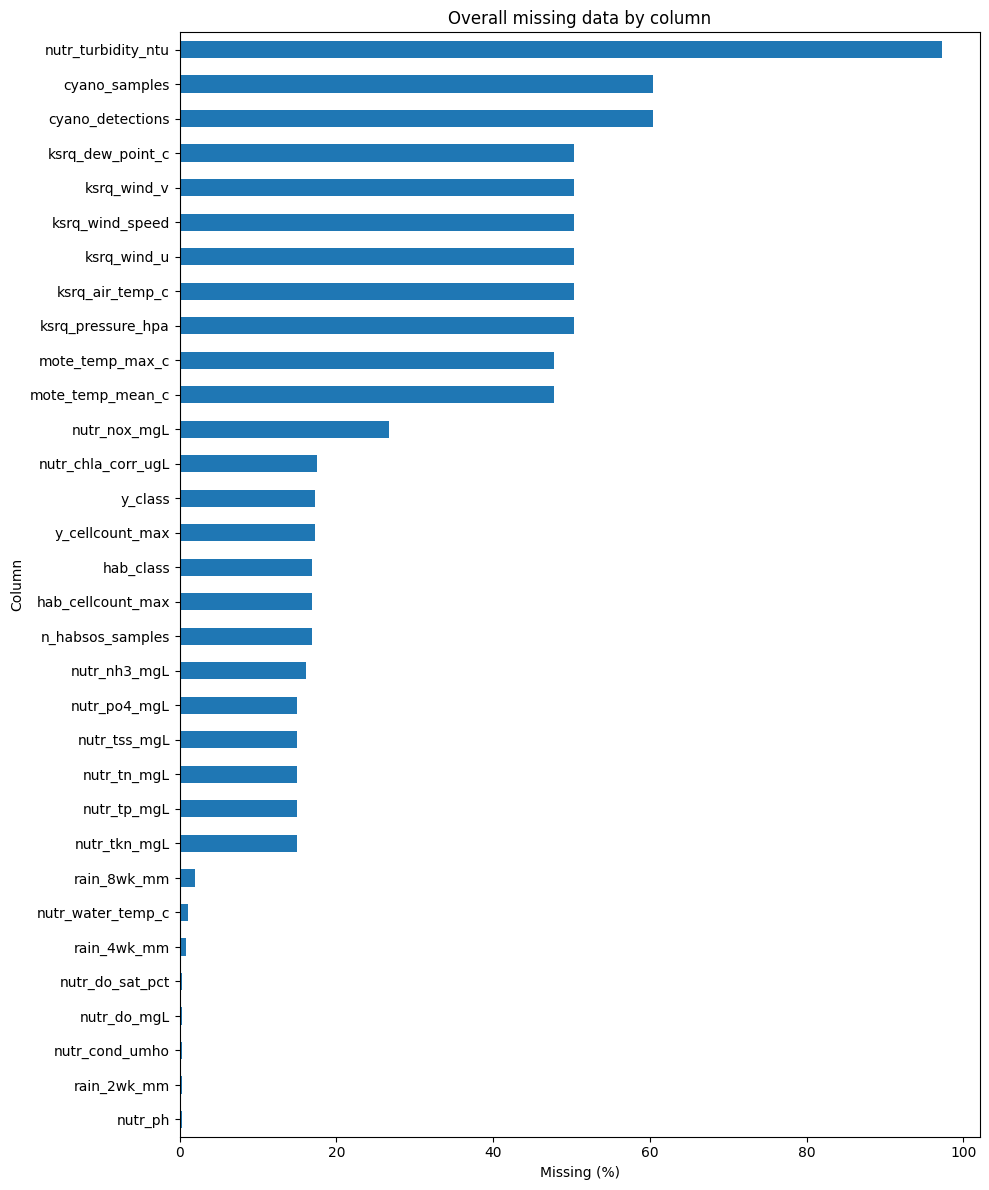

In [13]:
to_plot = missingness[missingness['missing_percent'] > 0].sort_values('missing_percent')

ax = to_plot['missing_percent'].plot(kind='barh', figsize=(10,12))
ax.set_title('Overall missing data by column')
ax.set_xlabel('Missing (%)')
ax.set_ylabel('Column')
plt.tight_layout()
plt.show()

Turbidity is the most incomplete feature, with approximately 97% of its values missing overall, while cyanotoxin, Mote water-temperature, and KSRQ variables also contain substantial missingness. 

These differences should be considered before modeling because highly incomplete features may provide too little information for the model to learn reliable patterns. 

Missing values should not be interpreted as zero, since they generally represent weeks in which a usable measurement was unavailable.

### Missingness by time split

In [14]:
desired_splits = ['train','validate','test','excluded']

missing_by_split = pd.DataFrame({
    s: df.loc[df['split']==s].isna().mean() * 100
    for s in desired_splits
})

missing_by_split.sort_values('train', ascending=False).round(1)

,train,validate,test,excluded
ksrq_wind_speed,100.000,0.000,0.000,26.000
ksrq_wind_v,100.000,0.000,0.000,26.000
ksrq_wind_u,100.000,0.000,0.000,26.000
ksrq_air_temp_c,100.000,0.000,0.000,26.000
ksrq_dew_point_c,100.000,0.000,0.000,26.000
ksrq_pressure_hpa,100.000,0.000,0.000,26.000
nutr_turbidity_ntu,100.000,90.600,100.000,95.200
cyano_samples,57.300,67.900,100.000,41.300
cyano_detections,57.300,67.900,100.000,41.300
mote_temp_mean_c,53.500,20.800,76.900,38.500


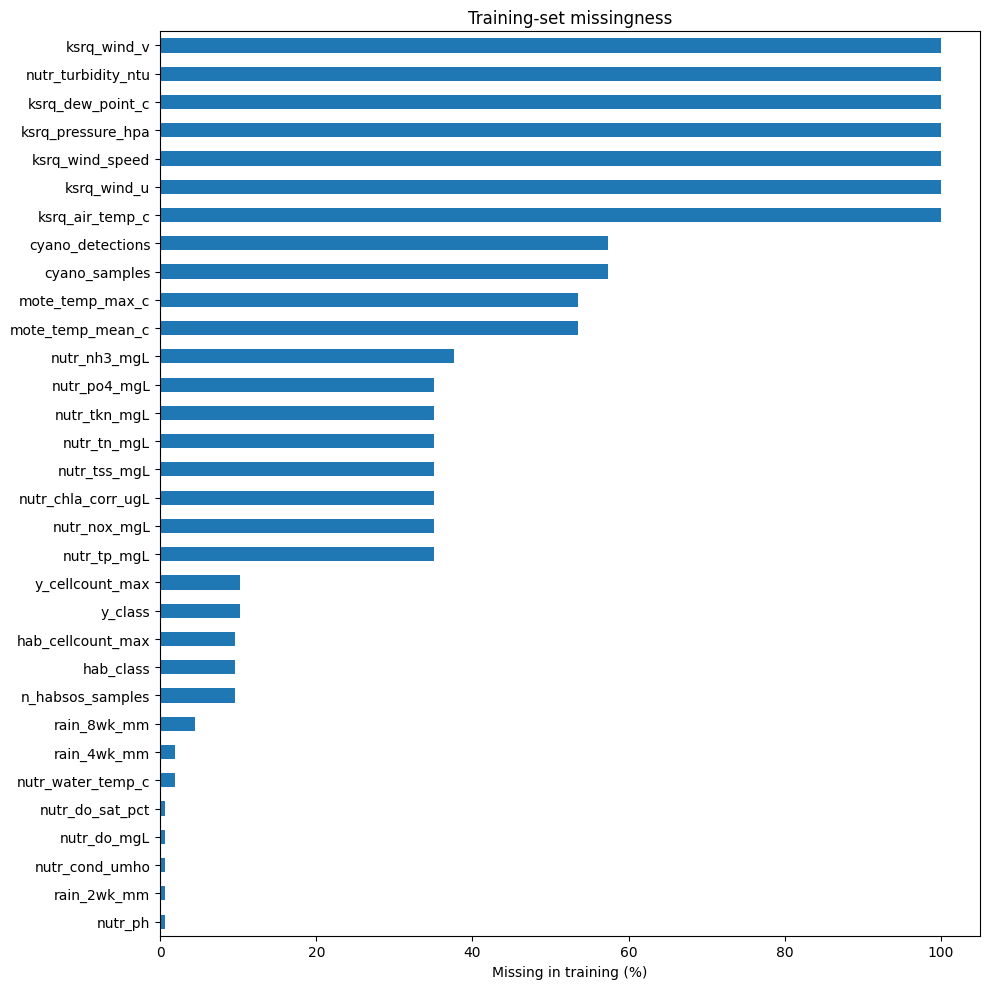

In [15]:
train_missing = missing_by_split['train'].sort_values(ascending=False)
ax = train_missing[train_missing > 0].sort_values().plot(kind='barh', figsize=(10,10))
ax.set_title('Training-set missingness')
ax.set_xlabel('Missing in training (%)')
plt.tight_layout()
plt.show()

**Key actual coverage problems**

- Every KSRQ measurement is 100% missing in training.
- `nutr_turbidity_ntu` is 100% missing in training.
- Cyanotoxin variables are 57.3% missing in training and 100% missing in test.
- Mote temperature is 53.5% missing in training and 76.9% missing in test.
- Several major nutrient variables are about 35–38% missing in training.


All KSRQ measurements are missing during the 2019–2021 training period because the KSRQ dataset begins after these years. Therefore, these features cannot be learned normally using the current training split. 

Turbidity is also completely unavailable during training, while Mote temperature, cyanotoxin measurements, and several nutrient variables have substantial missingness. These coverage differences should guide feature selection and the missing-data strategy before model training.

### Source availability flags

In [16]:
availability_cols = ['has_nutrients','has_ksrq','has_mote']

availability = (
    df.groupby('split')[availability_cols]
      .mean()
      .mul(100)
      .reindex(['train','validate','test','excluded'])
)

availability.round(1)

,has_nutrients,has_ksrq,has_mote
split,,,
train,74.500,0.000,46.500
validate,86.800,100.000,79.200
test,88.500,100.000,23.100
excluded,89.400,74.000,61.500


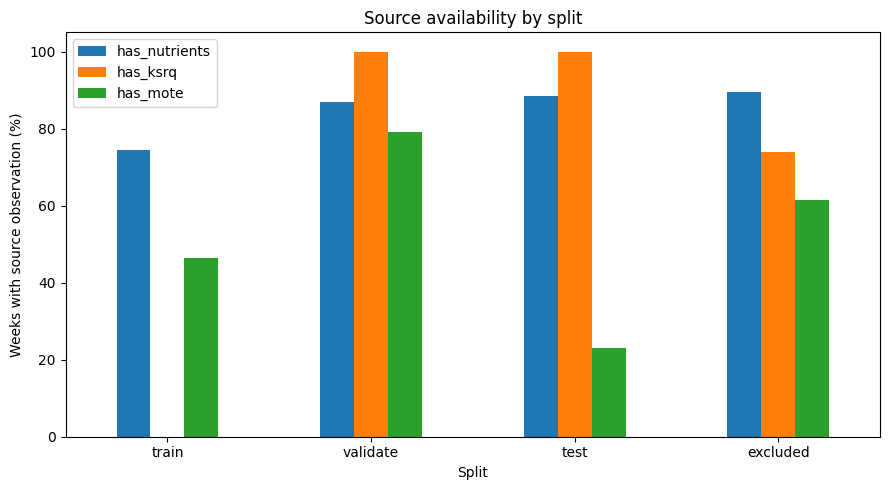

In [17]:
ax = availability.plot(kind='bar', figsize=(9,5))
ax.set_title('Source availability by split')
ax.set_xlabel('Split')
ax.set_ylabel('Weeks with source observation (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Key Source Availability Findings**

- The environmental data sources do not have uniform coverage across the study period.
- KSRQ observations are unavailable during the training years because that dataset begins later.
- Mote water-temperature measurements contain substantial gaps.
- Nutrient measurements carried forward for up to four weeks in the weekly model table.
- These differences indicate that source availability changes over time and should be considered when selecting features for the forecasting model.

## 6. Feature distributions — training data

Histograms below are restricted to training data so they describe what the model actually
learns from.

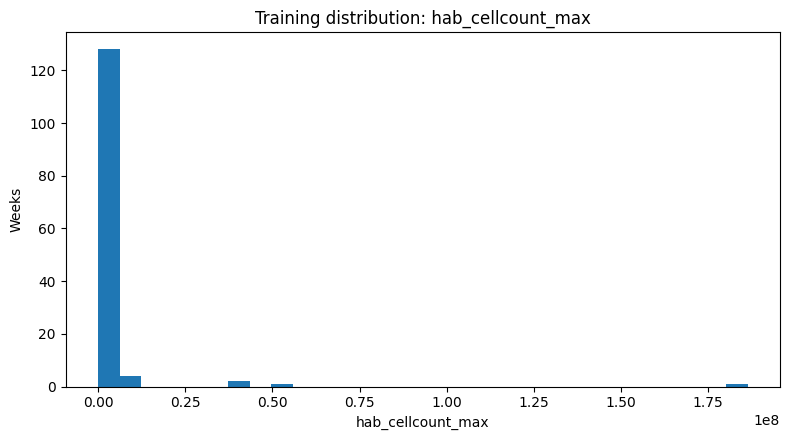

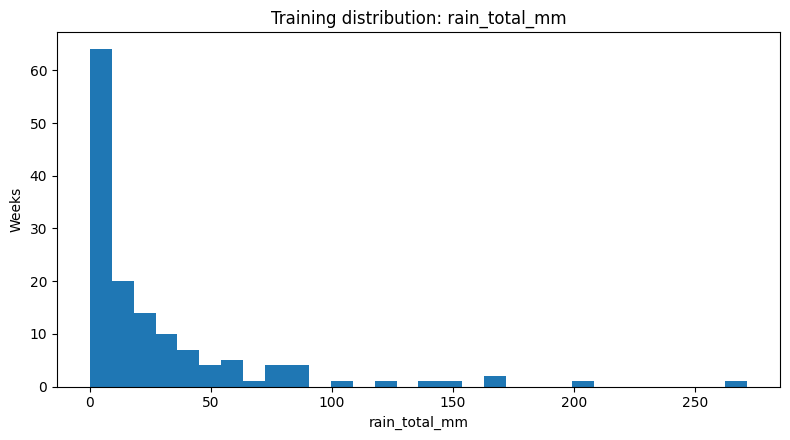

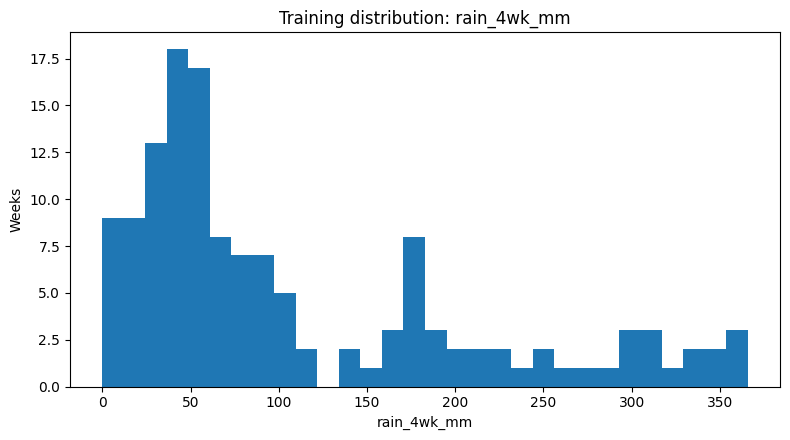

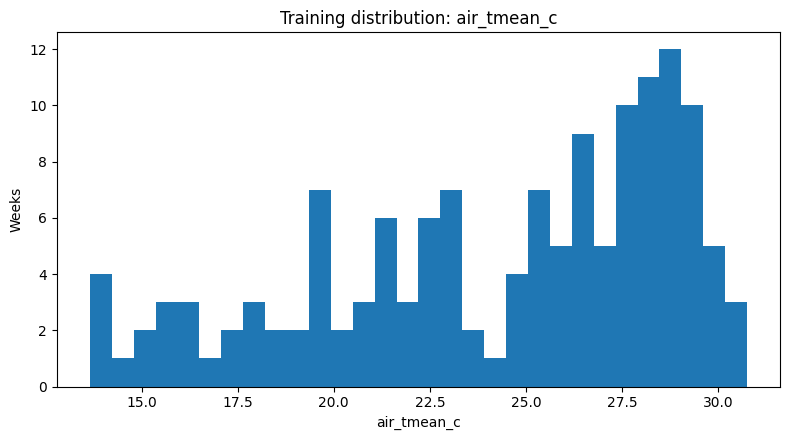

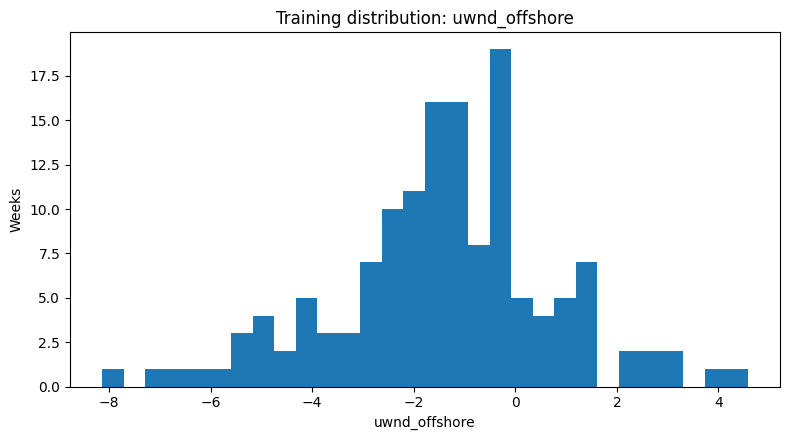

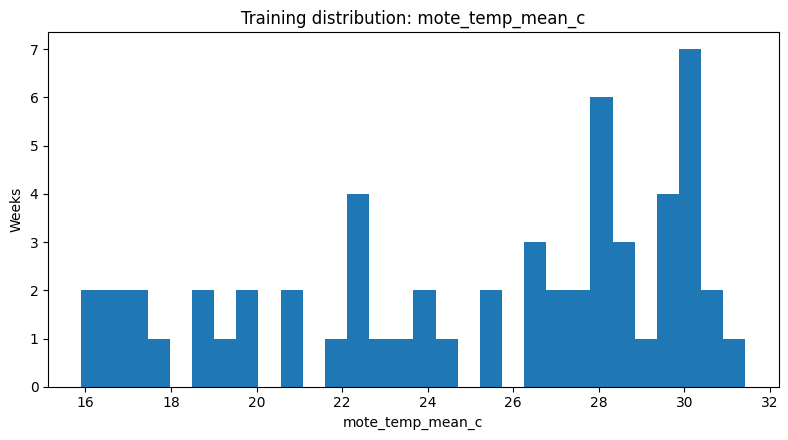

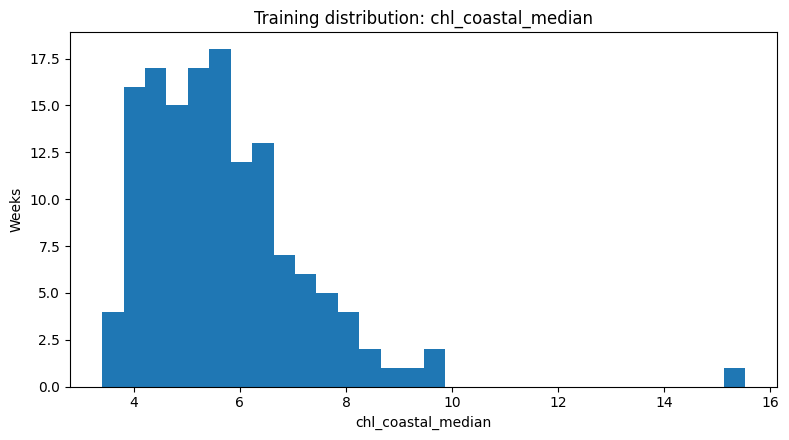

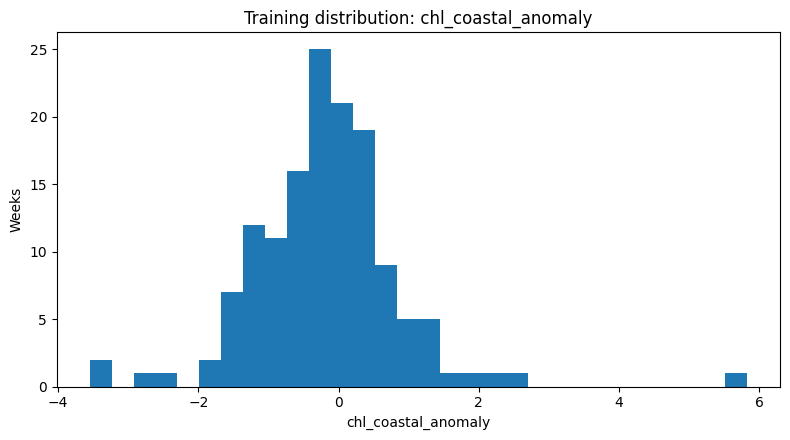

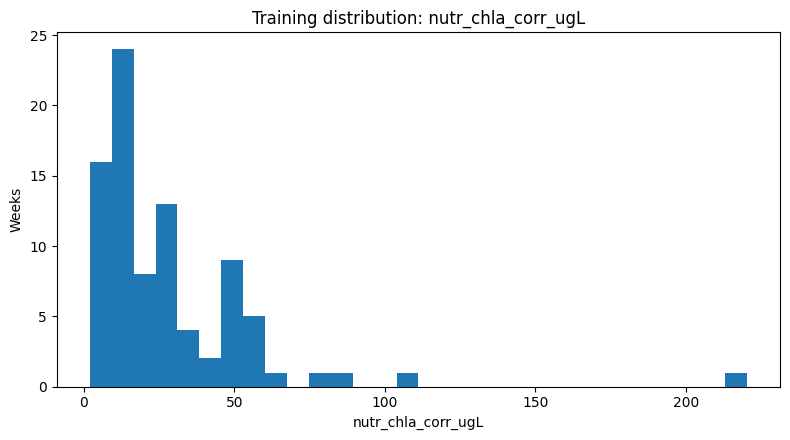

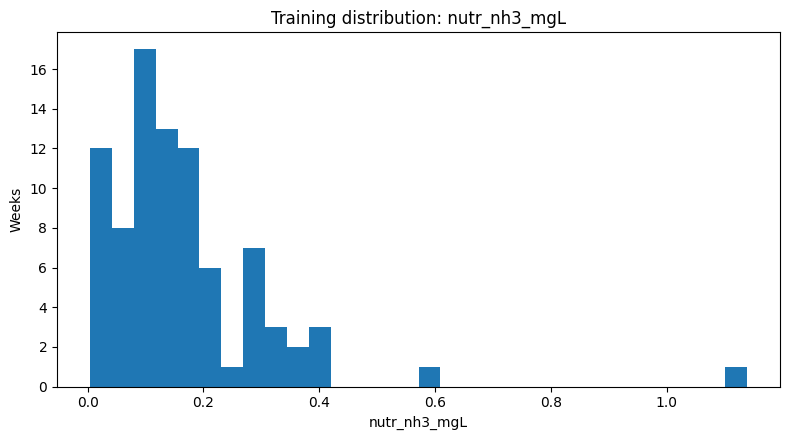

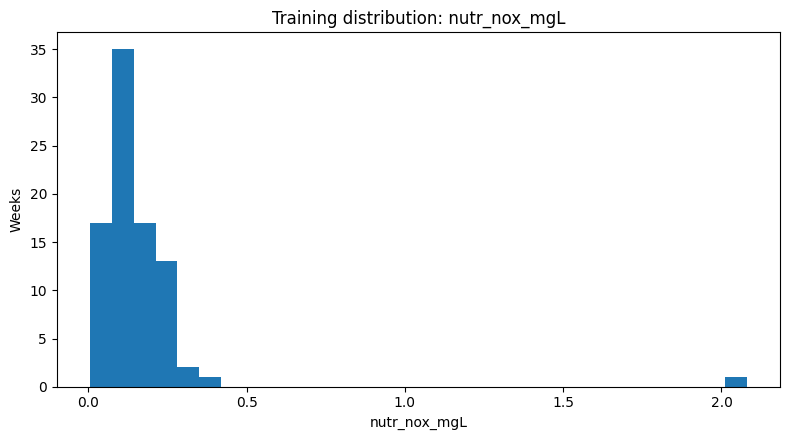

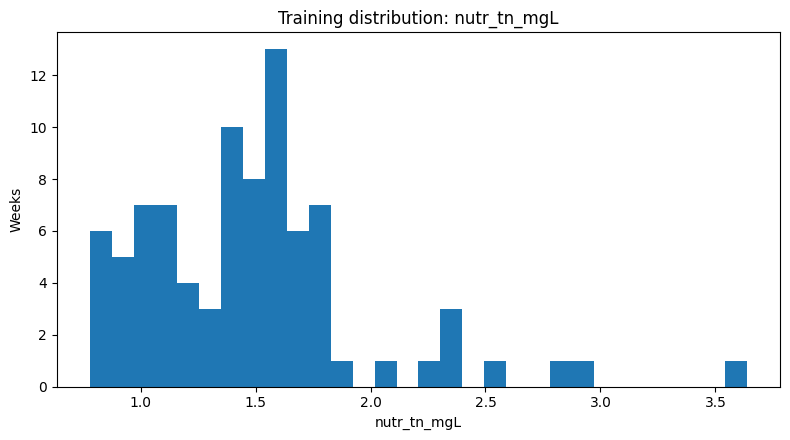

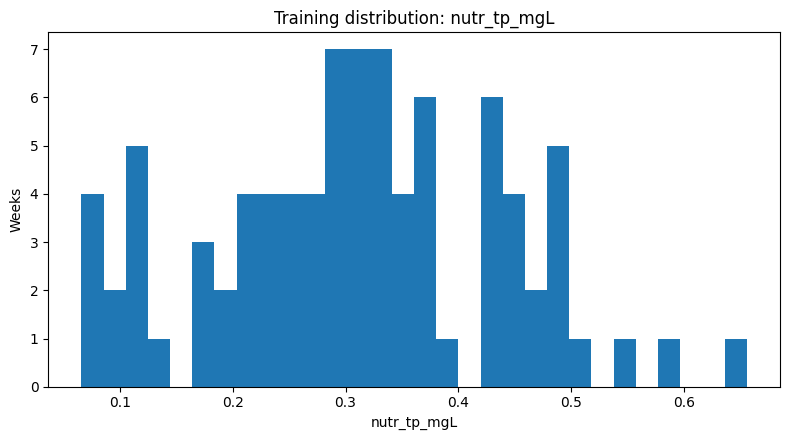

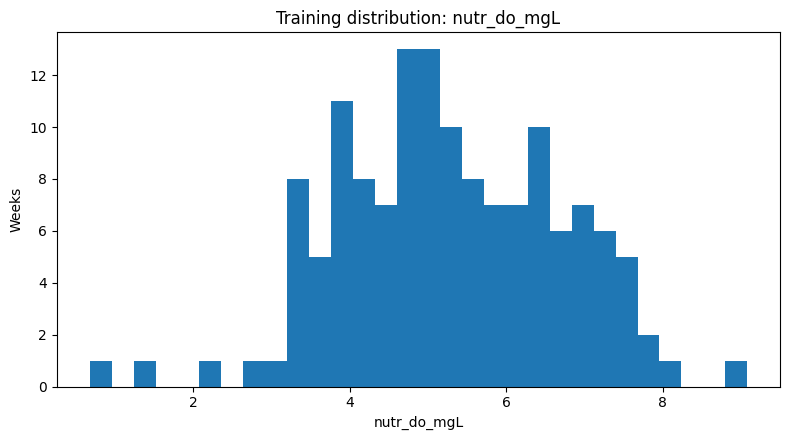

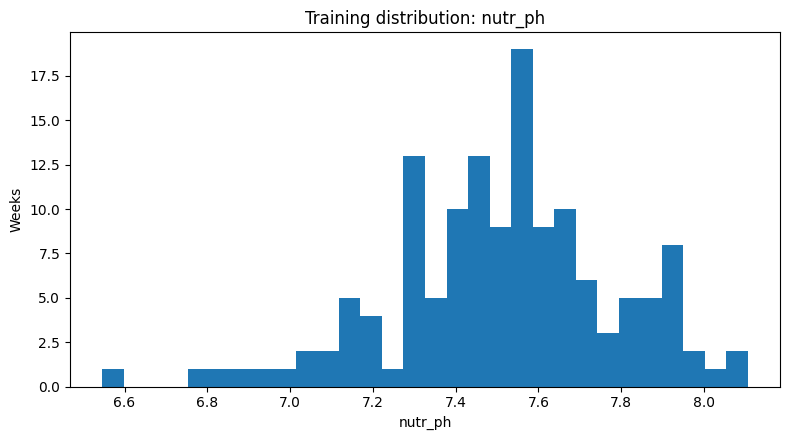

In [18]:
core_features = [
    'hab_cellcount_max',
    'rain_total_mm',
    'rain_4wk_mm',
    'air_tmean_c',
    'uwnd_offshore',
    'mote_temp_mean_c',
    'chl_coastal_median',
    'chl_coastal_anomaly',
    'nutr_chla_corr_ugL',
    'nutr_nh3_mgL',
    'nutr_nox_mgL',
    'nutr_tn_mgL',
    'nutr_tp_mgL',
    'nutr_do_mgL',
    'nutr_ph'
]

for feature in core_features:
    x = train_df[feature].dropna()
    if len(x) == 0:
        continue

    fig = plt.figure(figsize=(8,4.5))
    plt.hist(x, bins=30)
    plt.title(f'Training distribution: {feature}')
    plt.xlabel(feature)
    plt.ylabel('Weeks')
    plt.tight_layout()
    plt.show()

**Key Observations**

- HAB cell counts and rainfall-related variables are strongly right skewed.
- Temperature variables have a narrower range, while chlorophyll and several nutrient measurements also contain some elevated observations.
- Coastal chlorophyll values are somewhat right-skewed, with most weeks having lower-to-moderate concentrations and a smaller number of weeks showing elevated chlorophyll.
- The chlorophyll anomaly contains both negative and positive values, showing weeks when coastal chlorophyll was below or above the normal seasonal level.

### IQR outlier screen

In [19]:
outlier_rows = []

for feature in core_features:
    x = train_df[feature].dropna()
    if len(x) < 4:
        continue

    q1, q3 = x.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = ((x < lower) | (x > upper)).sum()

    outlier_rows.append({
        'feature': feature,
        'n': len(x),
        'min': x.min(),
        'median': x.median(),
        'max': x.max(),
        'skew': x.skew(),
        'iqr_outliers': int(n_out),
        'outlier_percent': 100*n_out/len(x)
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values('outlier_percent', ascending=False)
outlier_summary

,feature,n,min,median,max,skew,iqr_outliers,outlier_percent
0,hab_cellcount_max,136,0.000,"1,000.000","186,266,667.000",9.507,25,18.382
1,rain_total_mm,141,0.000,11.176,271.526,2.911,13,9.220
4,uwnd_offshore,141,-8.130,-1.329,4.576,-0.220,9,6.383
9,nutr_nh3_mgL,86,0.004,0.135,1.139,3.400,5,5.814
8,nutr_chla_corr_ugL,86,1.967,22.221,220.315,3.773,4,4.651
7,chl_coastal_anomaly,141,-3.548,-0.181,5.826,0.925,6,4.255
10,nutr_nox_mgL,86,0.004,0.123,2.081,7.659,3,3.488
11,nutr_tn_mgL,86,0.779,1.450,3.638,1.592,3,3.488
14,nutr_ph,140,6.546,7.527,8.106,-0.434,4,2.857
6,chl_coastal_median,141,3.404,5.460,15.524,2.198,4,2.837


Variables such as rainfall, chlorophyll, nutrient concentrations, and HAB cell counts, where real environmental extremes occur.

## 7. Current-week environmental features vs next-week HAB class

These comparisons use **training data only**.

/tmp/ipykernel_1096/3084991351.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=['Class 0','Class 1','Class 2'], showfliers=True)


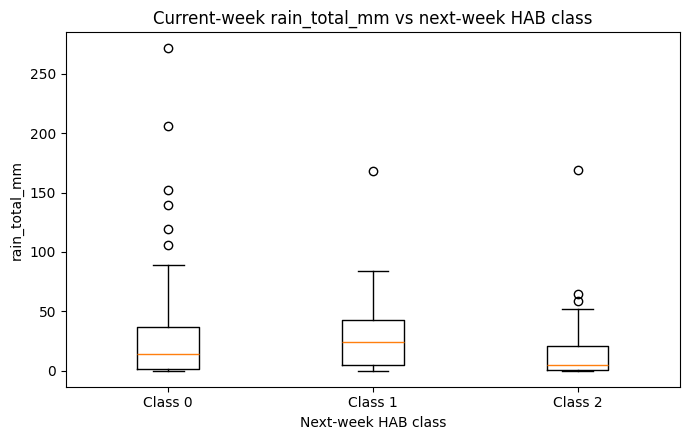

/tmp/ipykernel_1096/3084991351.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=['Class 0','Class 1','Class 2'], showfliers=True)


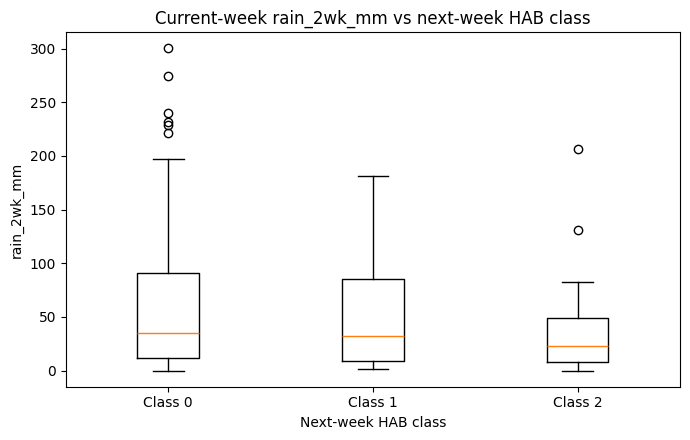

/tmp/ipykernel_1096/3084991351.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=['Class 0','Class 1','Class 2'], showfliers=True)


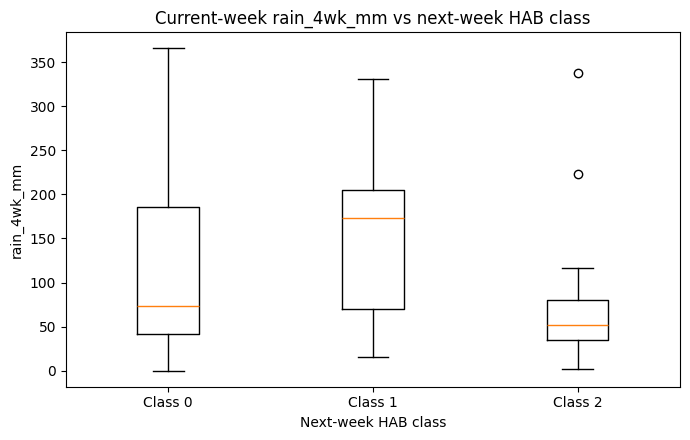

/tmp/ipykernel_1096/3084991351.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=['Class 0','Class 1','Class 2'], showfliers=True)


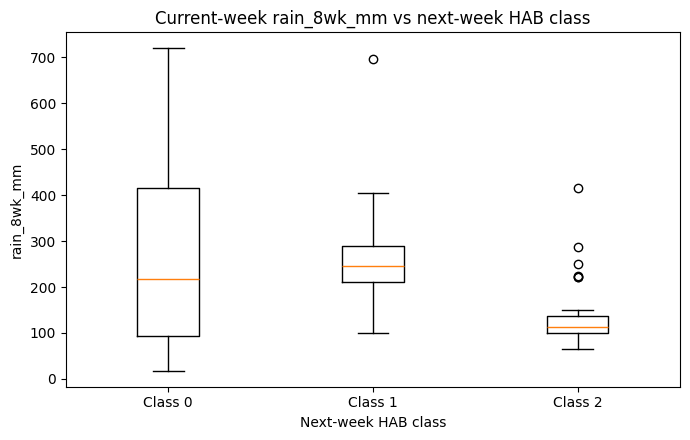

/tmp/ipykernel_1096/3084991351.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=['Class 0','Class 1','Class 2'], showfliers=True)


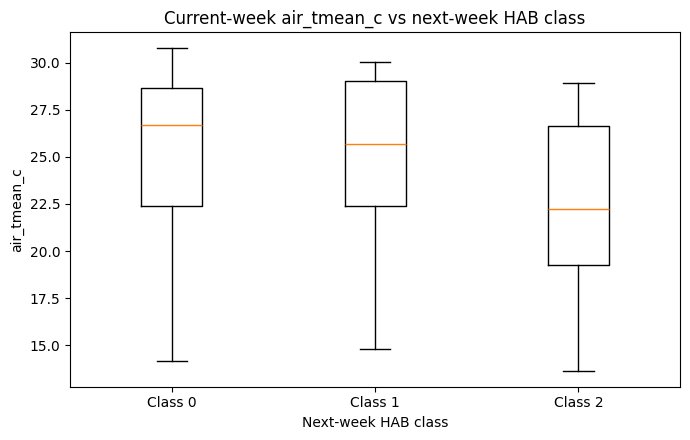

/tmp/ipykernel_1096/3084991351.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=['Class 0','Class 1','Class 2'], showfliers=True)


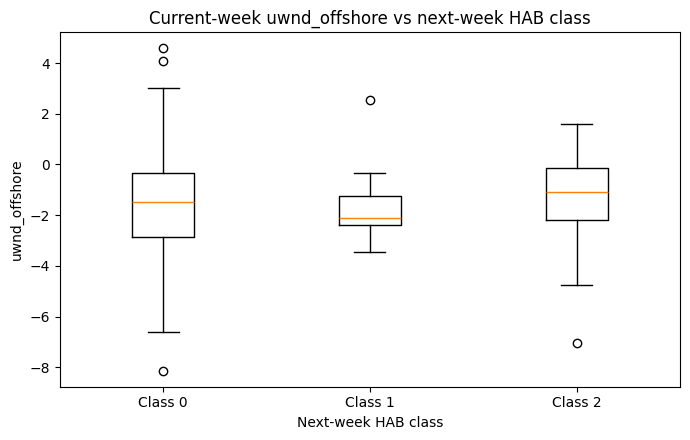

/tmp/ipykernel_1096/3084991351.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=['Class 0','Class 1','Class 2'], showfliers=True)


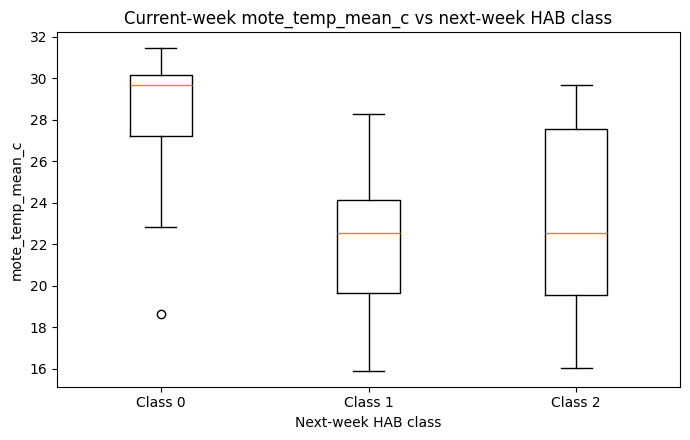

/tmp/ipykernel_1096/3084991351.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=['Class 0','Class 1','Class 2'], showfliers=True)


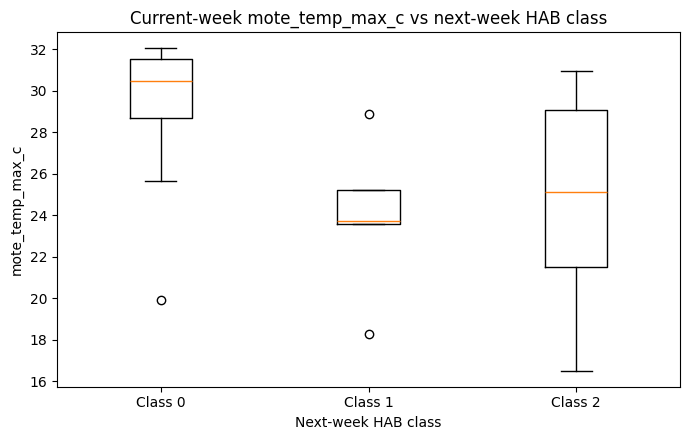

/tmp/ipykernel_1096/3084991351.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=['Class 0','Class 1','Class 2'], showfliers=True)


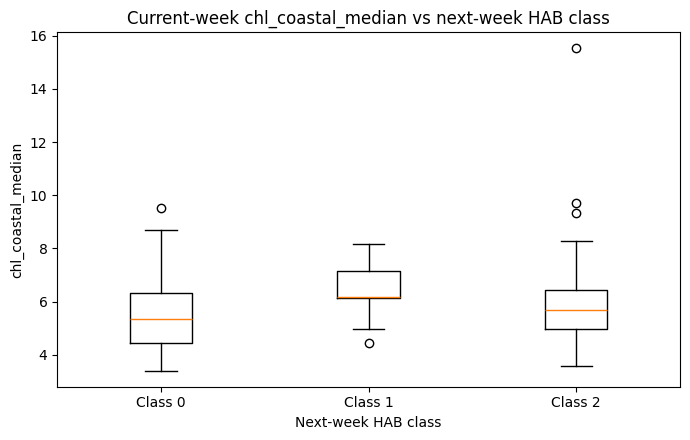

/tmp/ipykernel_1096/3084991351.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=['Class 0','Class 1','Class 2'], showfliers=True)


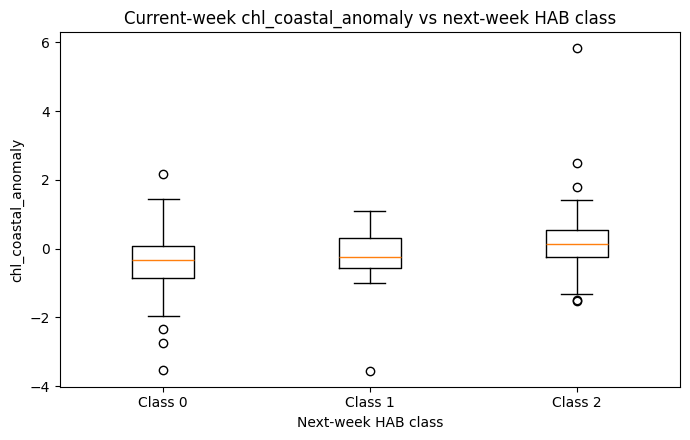

/tmp/ipykernel_1096/3084991351.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=['Class 0','Class 1','Class 2'], showfliers=True)


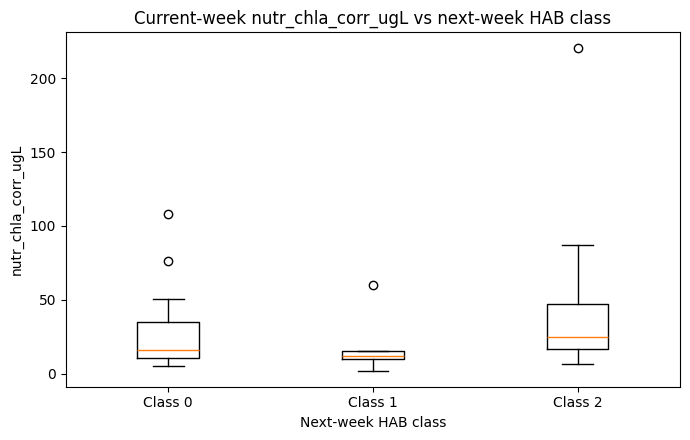

/tmp/ipykernel_1096/3084991351.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=['Class 0','Class 1','Class 2'], showfliers=True)


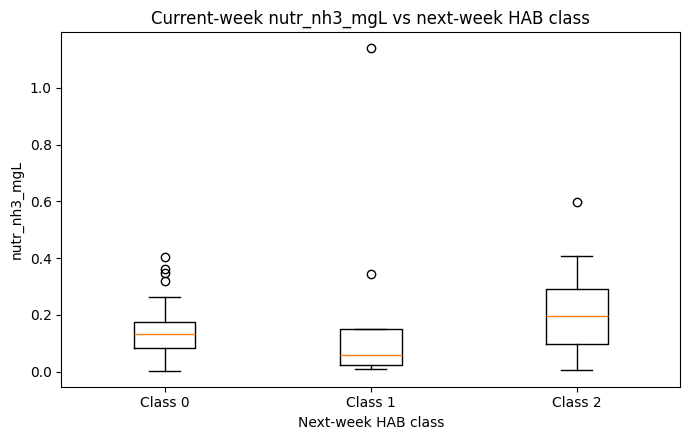

/tmp/ipykernel_1096/3084991351.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=['Class 0','Class 1','Class 2'], showfliers=True)


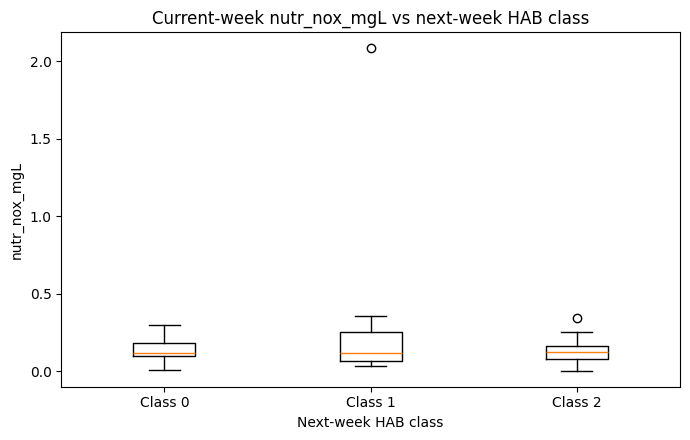

/tmp/ipykernel_1096/3084991351.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=['Class 0','Class 1','Class 2'], showfliers=True)


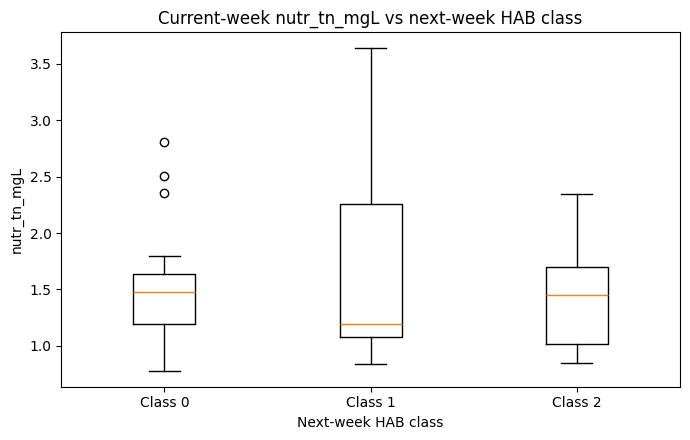

/tmp/ipykernel_1096/3084991351.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=['Class 0','Class 1','Class 2'], showfliers=True)


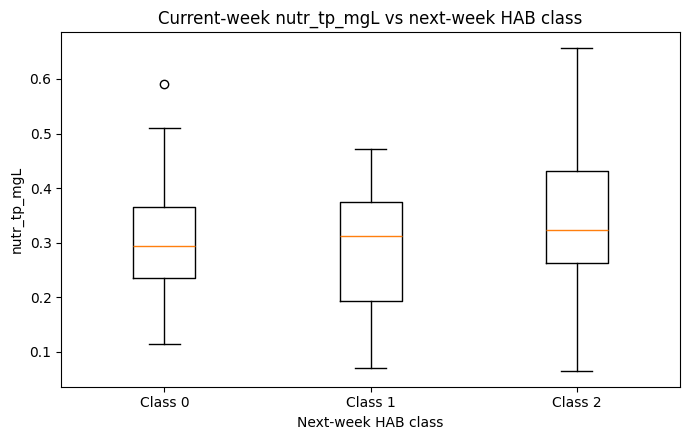

/tmp/ipykernel_1096/3084991351.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=['Class 0','Class 1','Class 2'], showfliers=True)


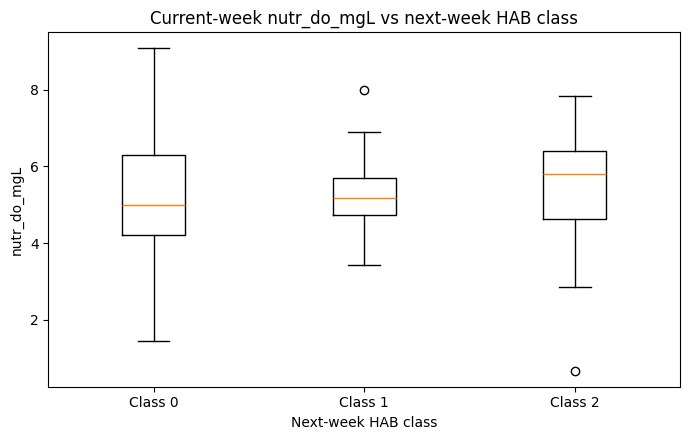

/tmp/ipykernel_1096/3084991351.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=['Class 0','Class 1','Class 2'], showfliers=True)


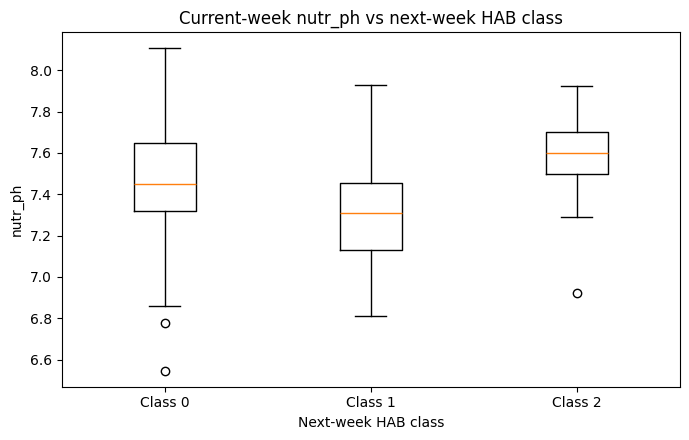

In [20]:
compare_features = [
    'rain_total_mm','rain_2wk_mm','rain_4wk_mm','rain_8wk_mm',
    'air_tmean_c','uwnd_offshore','mote_temp_mean_c','mote_temp_max_c',
    'chl_coastal_median','chl_coastal_anomaly',
    'nutr_chla_corr_ugL','nutr_nh3_mgL','nutr_nox_mgL',
    'nutr_tn_mgL','nutr_tp_mgL','nutr_do_mgL','nutr_ph'
]

for feature in compare_features:
    temp = train_df[['y_class', feature]].dropna()
    if temp.empty:
        continue

    groups = [
        temp.loc[temp['y_class']==cls, feature].values
        for cls in [0,1,2]
    ]

    fig = plt.figure(figsize=(7,4.5))
    plt.boxplot(groups, labels=['Class 0','Class 1','Class 2'], showfliers=True)
    plt.title(f'Current-week {feature} vs next-week HAB class')
    plt.xlabel('Next-week HAB class')
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

- Lower temperature was associated with Class 2 in this training sample.
- Lower water temperatures was assoicated with higher HAB classes.
- Postive coastal chlorophyll anamoly contain useful information for forecasting higher HAB conditions. 
- Class 1 showing the highest median accumulated rainfall. However,Class 1 contains only nine training observations
- Most individual nutrient variables show substantial overlap between HAB classes, suggesting that no single nutrient measurement clearly separates next-week HAB severity in the training data.

In [21]:
median_by_class = train_df.groupby('y_class')[compare_features].median().T
median_by_class.columns = ['Class 0 median','Class 1 median','Class 2 median']
median_by_class

,Class 0 median,Class 1 median,Class 2 median
rain_total_mm,13.970,24.384,4.572
rain_2wk_mm,35.052,32.258,22.987
rain_4wk_mm,73.914,172.974,51.308
rain_8wk_mm,216.916,245.872,114.046
air_tmean_c,26.706,25.675,22.222
uwnd_offshore,-1.462,-2.119,-1.080
mote_temp_mean_c,29.655,22.531,22.548
mote_temp_max_c,30.474,23.738,25.125
chl_coastal_median,5.333,6.187,5.677
chl_coastal_anomaly,-0.323,-0.248,0.133


In [22]:
sample_size_by_class = pd.DataFrame({
    f: train_df.groupby('y_class')[f].count()
    for f in compare_features
}).T

sample_size_by_class.columns = ['Class 0 n','Class 1 n','Class 2 n']
sample_size_by_class

,Class 0 n,Class 1 n,Class 2 n
rain_total_mm,91,9,41
rain_2wk_mm,91,9,40
rain_4wk_mm,91,9,38
rain_8wk_mm,87,9,38
air_tmean_c,91,9,41
uwnd_offshore,91,9,41
mote_temp_mean_c,23,5,29
mote_temp_max_c,23,5,29
chl_coastal_median,91,9,41
chl_coastal_anomaly,91,9,41


**Interpretation caution:** Class 1 has only nine training weeks. Mote temperature has only
57 labeled training observations total. Apparent class separation for sparse features can
therefore be unstable.

## 8. Spearman associations with next-week class

Spearman correlation is used because many variables are skewed and `y_class` is ordinal.

Direct HAB persistence variables are shown separately from environmental variables.

In [23]:
direct_features = ['hab_class','hab_cellcount_max','n_habsos_samples']
environmental_features = [
    c for c in train_df.select_dtypes(include=np.number).columns
    if c not in [
        'y_class','y_cellcount_max','low_coverage',
        'has_nutrients','has_ksrq','has_mote',
        'hab_class','hab_cellcount_max','n_habsos_samples'
    ]
]

direct_corr = (
    train_df[direct_features + ['y_class']]
    .corr(method='spearman')['y_class']
    .drop('y_class')
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

env_corr = (
    train_df[environmental_features + ['y_class']]
    .corr(method='spearman')['y_class']
    .drop('y_class')
    .dropna()
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print('Direct/current-HAB features')
display(direct_corr.to_frame('Spearman with y_class'))

print('Environmental features')
display(env_corr.to_frame('Spearman with y_class'))

Direct/current-HAB features


,Spearman with y_class
hab_class,0.825
hab_cellcount_max,0.722
n_habsos_samples,0.411


Environmental features


,Spearman with y_class
mote_temp_max_c,-0.539
mote_temp_mean_c,-0.537
air_tmax_c,-0.306
nutr_water_temp_c,-0.306
air_tmean_c,-0.292
air_tmin_c,-0.290
chl_coastal_anomaly,0.286
nutr_nh3_mgL,0.200
nutr_ph,0.195
rain_4wk_mm,-0.194


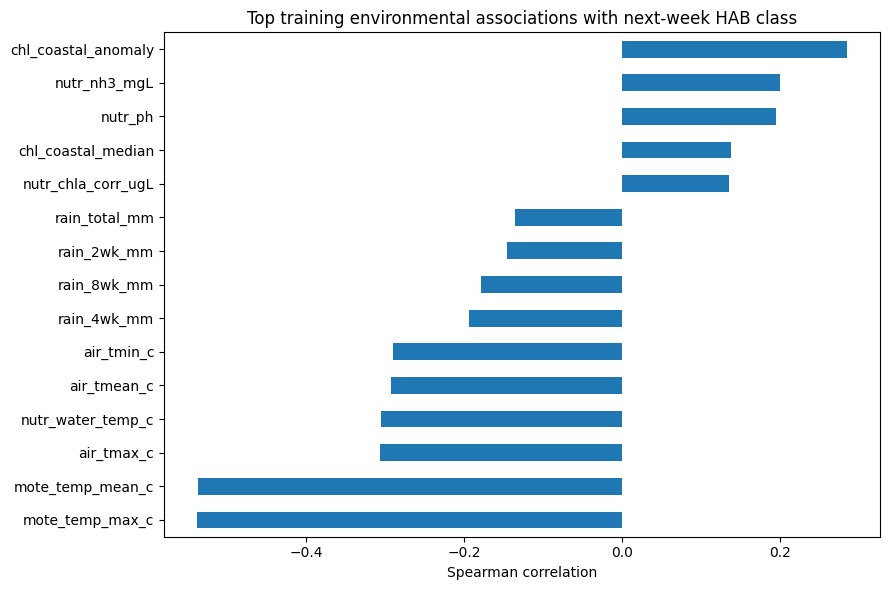

In [24]:
top_env = env_corr.head(15).sort_values()

ax = top_env.plot(kind='barh', figsize=(9,6))
ax.set_title('Top training environmental associations with next-week HAB class')
ax.set_xlabel('Spearman correlation')
plt.tight_layout()
plt.show()

**Actual result:** after the direct current-HAB variables, the largest environmental
associations are Mote temperature (around -0.54, but sparse), air temperature (around
-0.29 to -0.31), and coastal chlorophyll anomaly (+0.29). These are associations, not
causal findings.


Mote water temperature showed the strongest environmental association with next-week HAB class (Spearman ≈ −0.54), with lower observed water temperatures tending to occur before higher HAB classes.

Air temperature showed a moderate negative association with next-week HAB class (approximately −0.29 to −0.31). Higher HAB classes tended to follow cooler weeks, supporting the pattern observed in the boxplots.

Coastal chlorophyll anomaly showed a positive association with next-week HAB class (Spearman ≈ +0.29). Weeks with chlorophyll levels above their seasonal baseline tended to be followed by higher HAB classes, suggesting that chlorophyll anomaly may provide useful forecasting information.

Four-week rainfall showed negative association with next-week HAB class (approximately −0.19). This mean lower accumulated rainfall before higher classes.

## 9. Seasonality — training data only

In [26]:
season = train_df.copy()
season['month'] = season['week_start'].dt.month

monthly_counts = pd.crosstab(season['month'], season['y_class']).reindex(range(1,13), fill_value=0)
monthly_pct = monthly_counts.div(monthly_counts.sum(axis=1), axis=0) * 100
monthly_pct.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_pct.columns = ['Class 0','Class 1','Class 2']

monthly_pct.round(1)

,Class 0,Class 1,Class 2
Jan,58.300,0.000,41.700
Feb,58.300,16.700,25.000
Mar,64.300,0.000,35.700
Apr,69.200,0.000,30.800
May,61.500,0.000,38.500
Jun,69.200,0.000,30.800
Jul,81.800,9.100,9.100
Aug,84.600,15.400,0.000
Sep,100.000,0.000,0.000
Oct,50.000,10.000,40.000


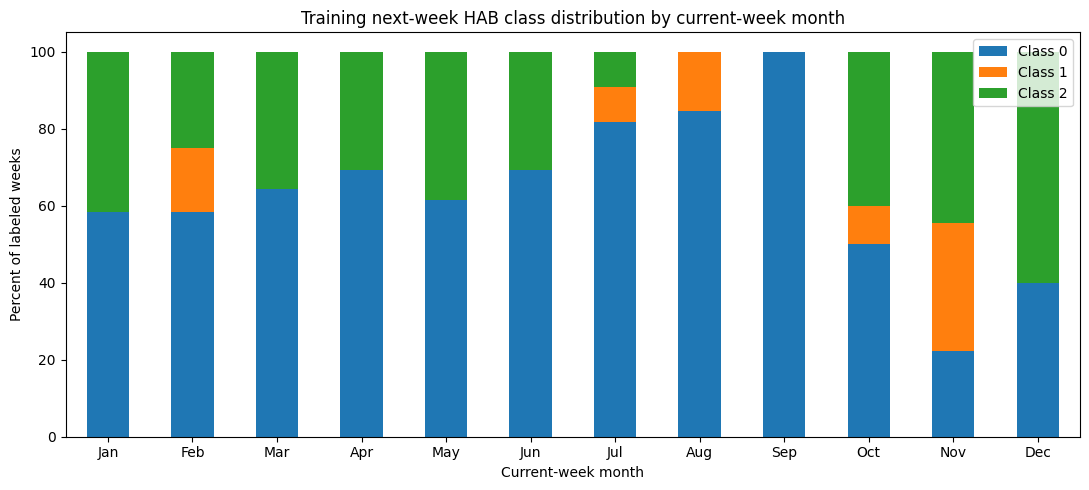

In [27]:
ax = monthly_pct.plot(kind='bar', stacked=True, figsize=(11,5))
ax.set_title('Training next-week HAB class distribution by current-week month')
ax.set_xlabel('Current-week month')
ax.set_ylabel('Percent of labeled weeks')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Actual result:** in 2019–2021, Class 2 is most common in the late-fall/winter portion of
the sample: December 60%, November 44.4%, January 41.7%, and October 40%. August and
September contain no Class-2 target weeks in the training sample. This is descriptive of
these training years only.

The training data show a seasonal pattern in next-week HAB severity. Class 2 occurred most frequently during late fall and winter, with the highest Class-2 proportions observed in December, November, January, and October. In contrast, no Class-2 target weeks occurred in August or September within the 2019–2021 training sample. This seasonal pattern may partly explain why cooler air and water temperatures were associated with higher HAB classes in earlier analyses.
